## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

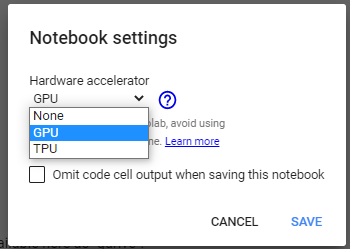

### Mount your google drive

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


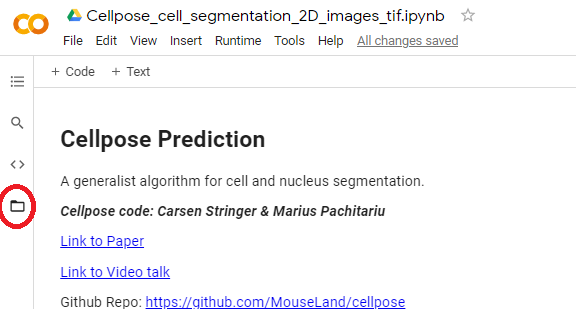

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

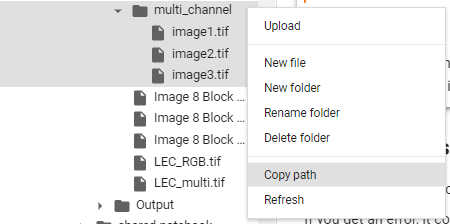

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [2]:
!uv pip install git+https://www.github.com/mouseland/cellpose.git
!uv pip install git+https://github.com/facebookresearch/dinov3.git

Using Python 3.12.13 environment at: /usr
Resolved 43 packages in 7.33s
Prepared 6 packages in 895ms
Installed 6 packages in 7ms
 + cellpose==4.1.2.dev121+gead065e1f (from git+https://www.github.com/mouseland/cellpose.git@ead065e1fee666ef74846752526d5882f7c0ad67)
 + fastremap==1.19.0
 + fill-voids==2.1.2
 + imagecodecs==2026.3.6
 + roifile==2026.2.10
 + segment-anything==1.0
Using Python 3.12.13 environment at: /usr
Resolved 49 packages in 2.59s
Prepared 5 packages in 663ms
Installed 5 packages in 20ms
 + dinov3==0.0.1 (from git+https://github.com/facebookresearch/dinov3.git@50001c6db58dbca7e7d06a5c5a9f1e078ca29197)
 + ftfy==6.3.1
 + lightning-utilities==0.15.3
 + submitit==1.5.4
 + torchmetrics==1.9.0


Check GPU and instantiate model - will download weights.

In [3]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

### You can also use other pretrained models, like the DINO models
# model = models.CellposeModel(gpu=True, pretrained_model="cpdino")
# model = models.CellposeModel(gpu=True, pretrained_model="cpdino-vitb")

creating new log file
[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.1.2.dev121+gead065e1f 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-06-11 09:49:15,650 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-06-11 09:49:15,651 [io INFO] 
cellpose version: 	4.1.2.dev121+gead065e1f 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-06-11 09:49:16,054 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-11 09:49:16,056 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-11 09:49:16,057 [core INFO] >>>> using GPU (CUDA)
2026-06-11 09:49:16,058 [models INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam_v2" to /root/.cellpose/models/cpsam_v2



100%|██████████| 1.15G/1.15G [00:06<00:00, 195MB/s]


2026-06-11 09:49:26,730 [models INFO] >>>> loading model /root/.cellpose/models/cpsam_v2


Input directory with your images:

In [4]:
# *** change to your google drive folder path ***
dir = "/content/drive/MyDrive/Cell Segmentation Google"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

1 images in folder:
Experiment-52_positions_s10-1_10x.tif


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [5]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (1040, 1388, 3). Assuming channel dimension is last with 3 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a third stain (described below), you can run segmentation with all channels.

In [6]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '2' # @param ['None', 0, 1, 2, 3, 4, 5]

/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


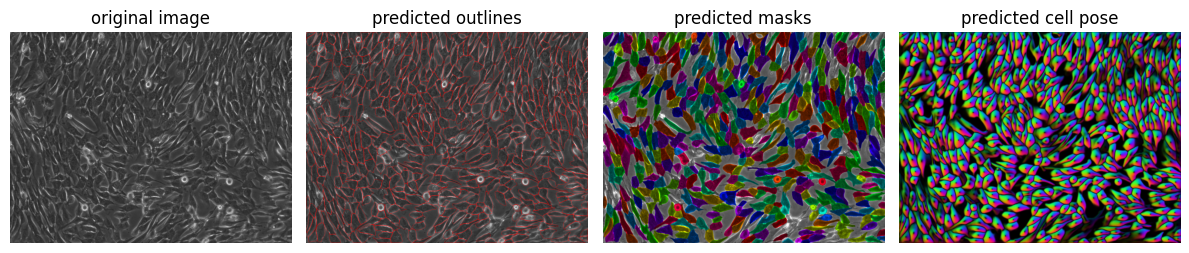

In [7]:
if img.ndim == 2:
    img = img[:, :, np.newaxis] # Convert (H, W) to (H, W, 1)
    print(f"Image was 2D, reshaped to {img.shape} for channel selection.")

selected_channels = []
num_channels = img.shape[-1]
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  channel_idx = int(c)
  if channel_idx >= num_channels: # Use >= as channel indices are 0-based.
    print(f"Warning: Selected channel index {channel_idx} is out of bounds for an image with {num_channels} channel(s). Skipping this channel.")
    continue # Skip this channel as it's out of bounds
  selected_channels.append(channel_idx)

# If no channels were explicitly selected but the image has channels, default to the first channel.
if not selected_channels and num_channels > 0:
    selected_channels = [0]
    print(f"No channels explicitly selected or all selected channels were out of bounds, defaulting to channel 0 for image of shape {img.shape}.")
elif not selected_channels and num_channels == 0:
    assert False, "Image has no channels to process."

img_selected_channels = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()

---------------------------------------------------

In [ ]:
img = io.imread(files[1])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (512, 512, 3). Assuming channel dimension is last with 3 channels


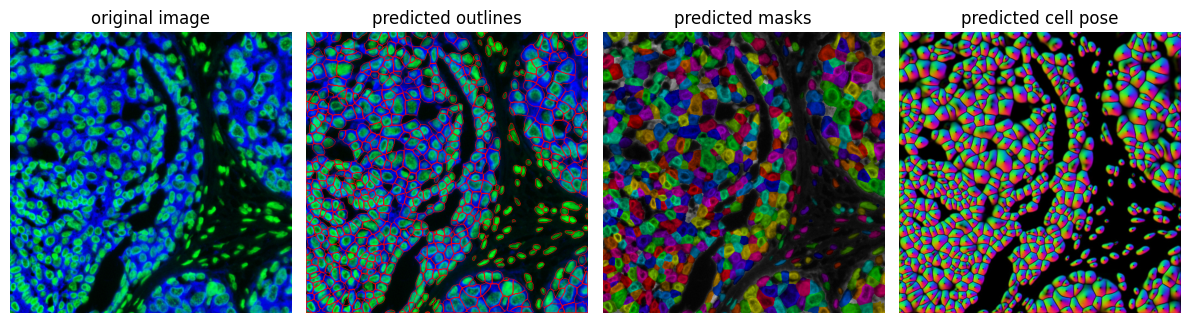

In [ ]:
if img.ndim == 2:
    img = img[:, :, np.newaxis] # Convert (H, W) to (H, W, 1)
    print(f"Image was 2D, reshaped to {img.shape} for channel selection.")

selected_channels = []
num_channels = img.shape[-1]
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  channel_idx = int(c)
  if channel_idx >= num_channels: # Use >= as channel indices are 0-based.
    print(f"Warning: Selected channel index {channel_idx} is out of bounds for an image with {num_channels} channel(s). Skipping this channel.")
    continue # Skip this channel as it's out of bounds
  selected_channels.append(channel_idx)

# If no channels were explicitly selected but the image has channels, default to the first channel.
if not selected_channels and num_channels > 0:
    selected_channels = [0]
    print(f"No channels explicitly selected or all selected channels were out of bounds, defaulting to channel 0 for image of shape {img.shape}.")
elif not selected_channels and num_channels == 0:
    assert False, "Image has no channels to process."

img_selected_channels = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()

In [ ]:
img = io.imread(files[2])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (470, 486). Assuming channel dimension is last with 486 channels


Image was 2D, reshaped to (470, 486, 1) for channel selection.


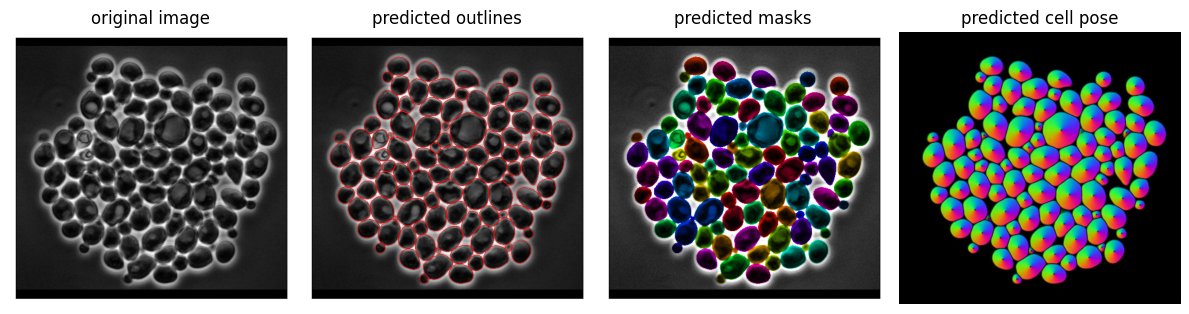

In [ ]:
if img.ndim == 2:
    img = img[:, :, np.newaxis] # Convert (H, W) to (H, W, 1)
    print(f"Image was 2D, reshaped to {img.shape} for channel selection.")

selected_channels = []
num_channels = img.shape[-1]
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  channel_idx = int(c)
  if channel_idx >= num_channels: # Use >= as channel indices are 0-based.
    print(f"Warning: Selected channel index {channel_idx} is out of bounds for an image with {num_channels} channel(s). Skipping this channel.")
    continue # Skip this channel as it's out of bounds
  selected_channels.append(channel_idx)

# If no channels were explicitly selected but the image has channels, default to the first channel.
if not selected_channels and num_channels > 0:
    selected_channels = [0]
    print(f"No channels explicitly selected or all selected channels were out of bounds, defaulting to channel 0 for image of shape {img.shape}.")
elif not selected_channels and num_channels == 0:
    assert False, "Image has no channels to process."

img_selected_channels = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()

In [ ]:
img = io.imread(files[3])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (470, 469). Assuming channel dimension is last with 469 channels


Image was 2D, reshaped to (470, 469, 1) for channel selection.


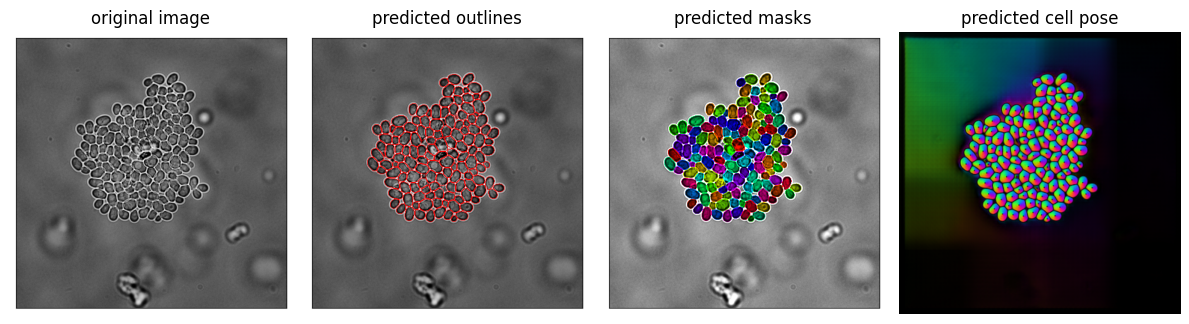

In [ ]:
if img.ndim == 2:
    img = img[:, :, np.newaxis] # Convert (H, W) to (H, W, 1)
    print(f"Image was 2D, reshaped to {img.shape} for channel selection.")

selected_channels = []
num_channels = img.shape[-1]
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  channel_idx = int(c)
  if channel_idx >= num_channels: # Use >= as channel indices are 0-based.
    print(f"Warning: Selected channel index {channel_idx} is out of bounds for an image with {num_channels} channel(s). Skipping this channel.")
    continue # Skip this channel as it's out of bounds
  selected_channels.append(channel_idx)

# If no channels were explicitly selected but the image has channels, default to the first channel.
if not selected_channels and num_channels > 0:
    selected_channels = [0]
    print(f"No channels explicitly selected or all selected channels were out of bounds, defaulting to channel 0 for image of shape {img.shape}.")
elif not selected_channels and num_channels == 0:
    assert False, "Image has no channels to process."

img_selected_channels = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()

In [ ]:
img = io.imread(files[4])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (256, 256, 3). Assuming channel dimension is last with 3 channels


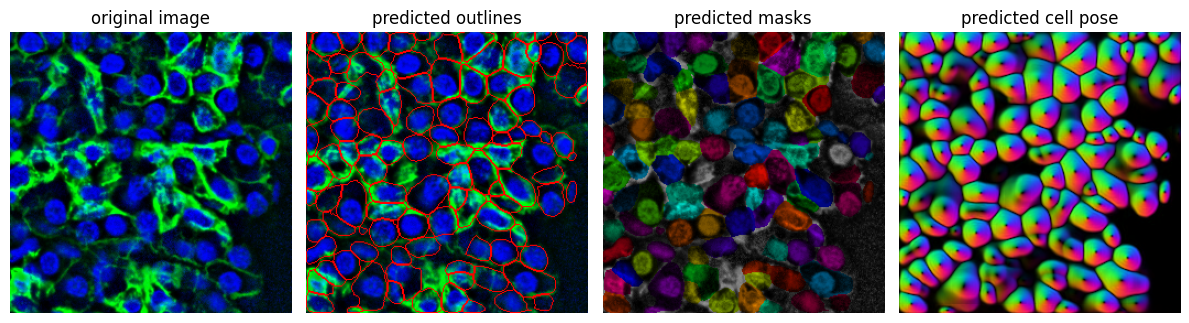

In [ ]:
if img.ndim == 2:
    img = img[:, :, np.newaxis] # Convert (H, W) to (H, W, 1)
    print(f"Image was 2D, reshaped to {img.shape} for channel selection.")

selected_channels = []
num_channels = img.shape[-1]
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  channel_idx = int(c)
  if channel_idx >= num_channels: # Use >= as channel indices are 0-based.
    print(f"Warning: Selected channel index {channel_idx} is out of bounds for an image with {num_channels} channel(s). Skipping this channel.")
    continue # Skip this channel as it's out of bounds
  selected_channels.append(channel_idx)

# If no channels were explicitly selected but the image has channels, default to the first channel.
if not selected_channels and num_channels > 0:
    selected_channels = [0]
    print(f"No channels explicitly selected or all selected channels were out of bounds, defaulting to channel 0 for image of shape {img.shape}.")
elif not selected_channels and num_channels == 0:
    assert False, "Image has no channels to process."

img_selected_channels = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()

## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [ ]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

100%|██████████| 5/5 [00:16<00:00,  3.27s/it]


if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

loading images


100%|██████████| 5/5 [00:00<00:00, 80.26it/s]

running cellpose-SAM
2026-06-10 06:40:57,634 [utils INFO] 0%|          | 0/5 [00:00<?, ?it/s]


2026-06-10 06:41:11,292 [utils INFO] 100%|##########| 5/5 [00:13<00:00,  2.73s/it]
saving masks


100%|██████████| 5/5 [00:00<00:00, 92.03it/s]


to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.name + "_masks" + masks_ext), masks[i])
    io.save_rois(masks[i], f)

100%|██████████| 5/5 [00:01<00:00,  4.84it/s]


In [ ]:
import shutil
from google.colab import files

# Define the output directory for the zipped masks
output_zip_name = 'cellpose_masks'
output_zip_path = Path(output_zip_name)

# Create a zip archive of the directory where masks were saved
# The masks were saved directly into the 'dir' variable in previous steps.
# We will zip the entire 'dir' folder which contains both images and masks.
# Alternatively, if you only want the masks, you could create a new directory for masks only.
print(f"Creating zip archive from {dir}...")
shutil.make_archive(output_zip_path, 'zip', dir)
print(f"Zip archive created: {output_zip_path}.zip")

# Download the zipped file
print("Downloading the zip file...")
files.download(str(output_zip_path) + '.zip')
print("Download initiated.")

Creating zip archive from /content/drive/MyDrive/Cell Segmentation Google...
Zip archive created: cellpose_masks.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.
